---

## **DIPLOME UNIVERSITAIRE**
## **SORBONNE DATA ANALYTICS**
---
## **Projet Machine Learning**
## **Classification des genres musicaux**

---
*Professeur* :\
FAIK Lina\
linafaik08@gmail.com\
\
*Etudiants* :\
KOENIG Camille\
camille.koenig@gmail.com\
MERCHAN Diego\
diegomerchanm@gmail.com\
PHAN NGUYEN Jayson\
jaysonphannguyenpro@gmail.com\
BIZOT Xia\
xiabizot@free.fr


Promotion 007

Mars 2026

---
**Jeu de données kaggle : FMA : A Dataset For Music Analysis – Format small**

https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium

---

---

## NOTEBOOK 1 - EDA décisionnelle

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C4–C6 | 1. Configuration | Imports, chemins relatifs, seed, versions |
| C7–C8 | 2. Acquisition | Inspection ZIP, extraction idempotente |
| C9–C13 | 3. Validation technique | Quality gates, cohérence IDs, décodage audio, environnement |
| C14 | 4.1 Sortie 1 | Synthèse Go/No-Go |
| C15 | 4.2 Sortie 2 | Distributions genre_top, bit_rate, durée |
| C16–C17 | 4.3 Sortie 3 | Sous-genres, waveform + spectrogramme |
| C18–C19 | 4.4 Sortie 4 | Mismatch, combos multi-label, biais artiste |
| C20–C21 | 4.5 Sortie 5 | Focus Rock & International, heatmap, histogrammes |
| C22–C23 | 4.6 Sortie 6 | Biais artiste, Blue Dot Sessions |
| C24–C26 | 4.7 Sortie 7 | Biais temporel, durée/mismatch, évolution |
| C27 | 5. Décisions figées | Standardisation, stratégie labels, split |

---

### Décisions prises dans ce notebook (résumé)

- **Périmètre** : FMA Small uniquement — 8 000 MP3 + metadata (tracks.csv, genres.csv)
- **Extraction features** : maison via librosa (features.csv FMA non utilisé)
- **Standardisation audio** : mono, sr=22 050 Hz, fenêtre=30s
- **Stratégie labels** : genre_top (8 classes) + top-k sous-genres (k=3) si temps
- **Split** : group split par artiste (préféré) ou stratified + documentation biais
- **Mismatch** : indicateur d'ambiguïté/hiérarchie — *pas* preuve de mauvais étiquetage

---

### Hypothèse testable issue de l'EDA

> Les genres à mismatch élevé (International 68 %, Rock 64 %) et/ou à forte concentration artiste (Instrumental : Blue Dot Sessions = 20,8 %) produiront davantage de confusions dans la matrice de confusion que les genres cohérents (Hip-Hop 12 %, Folk 23 %).

---

## Analyse EDA — FMA Small

### Qualité du dataset

Le dataset est techniquement propre : 8 000 MP3 alignés avec la metadata, zéro valeur manquante sur les colonnes critiques, zéro doublon, durées toutes supérieures à 30s et bitrates de bonne qualité. L'extraction audio peut démarrer sans nettoyage préalable.

### Structure des genres

Les 8 genres sont parfaitement équilibrés (1 000 pistes chacun), ce qui simplifie la modélisation : pas de stratégie anti-déséquilibre nécessaire. En revanche, cet équilibre masque une hétérogénéité profonde — certains genres sont cohérents (Hip-Hop, Folk), d'autres sont de purs agrégats stylistiques (Rock) ou géographiques (International).

### Sous-genres et mismatch

47% des pistes portent plusieurs sous-genres, ce qui justifie l'approche top-k. Le mismatch atteint 42% globalement mais varie fortement : Hip-Hop (12%) est le genre le plus cohérent, International (68%) et Rock (64%) les plus poreux. Ce n'est pas une erreur de labellisation — c'est un indicateur d'ambiguïté structurelle qui permettra d'expliquer les confusions du modèle.

### Biais artiste et temporel

Le genre Instrumental est dominé à 37% par 5 bibliothèques de musique royalty-free, dont Blue Dot Sessions seul représente 20,8% de la classe, concentrées sur 2015-2016. Le modèle risque d'apprendre le style de ces bibliothèques plutôt que les caractéristiques génériques du genre. Un split par artiste est fortement recommandé.

### Ce qu'on attend de la modélisation

Hip-Hop et Folk seront probablement les mieux classés. Rock et International produiront le plus de confusions. Instrumental sera pénalisé par le biais artiste si le split n'est pas fait par artiste. Cette hypothèse sera validée par la matrice de confusion en Phase 3.

---

---
## Classification musicale (FMA) : du ZIP à une EDA décisionnelle
---

### 0. Objectif du notebook

Ce notebook est un **livrable de pipeline (EDA décisionnelle)**. Il couvre la chaîne entière depuis l'acquisition des données brutes (ZIP) jusqu'aux **décisions figées** avant modélisation.

Il est conçu pour être :
- **reproductible** (chemins relatifs),
- **idempotent** (relançable sans réextraire si les fichiers sont conformes),
- **traçable** (quality gates go/no-go explicites),
- **orienté objectifs** : produire des sorties rapport-ready qui justifient le cadrage.

Le fil directeur est de justifier une stratégie d'étiquetage plus fin :
- baseline `genre_top` (macro, 8 classes) ;
- exploitation des sous-genres (top-k / multi-label) ;
- analyse transverse `mismatch` (ambiguïté/hiérarchie des labels, pas preuve de mauvais étiquetage) ;
- diagnostic des biais (généralisation).

---

### 1. Configuration & structure du pipeline

#### 1.1. Imports
Une seule cellule d'imports :
- fichiers : `pathlib`, `zipfile`
- données : `pandas`, `numpy`
- visualisation : `matplotlib`
- utilitaires : `ast`, `collections`

#### 1.2. Chemins relatifs & organisation
Principe : tout est relatif au dossier du notebook. Les données brutes extraites sont stockées dans `data/raw/` (non modifiées).

- `RAW_DIR = BASE / "data" / "raw"`
- Audio small : `data/raw/fma_small/fma_small/`
- Métadonnées : `data/raw/fma_metadata/`
- ZIP : `archive.zip` recherché dans `BASE` ou `BASE.parent`

Justifications :
- chemins relatifs → exécution sur n'importe quelle machine sans modifier le code ;
- `data/raw/` → séparation claire entre raw et données transformées (traçabilité).

#### 1.3. Reproductibilité & traçabilité
- versions (Python, pandas, numpy) ;
- chemins résolus (`BASE`, `RAW_DIR`, `AUDIO_DIR`, `META_DIR`, `ZIP_PATH`) ;
- graine globale pour rendre les échantillonnages déterministes.

---

### 2. Acquisition des données (depuis le ZIP)

#### 2.1. Inspection du ZIP (preuve de contenu)
Prouver que le ZIP contient plusieurs sous-ensembles et justifier une extraction limitée au périmètre utile :
- répertoires racines (`fma_small`, `fma_metadata`, `fma_medium`, …) + comptage par racine
- conclusion : extraction `fma_small` + `fma_metadata` ; `fma_medium` hors scope

#### 2.2. Extraction sélective idempotente
Extraire uniquement si nécessaire (sinon skip) :
- fichiers attendus : `tracks.csv`, `genres.csv`, `mp3_count == 8000`
- extraction sélective vers `RAW_DIR` uniquement si non-conformité
- idempotence : relancer le notebook ne ré-extrait pas les 8 000 MP3 si déjà conformes

---

### 3. Validation technique du raw (go/no-go)

Objectif : conclure **Dataset exploitable : OUI/NON** sur des critères vérifiables.

#### 3.1. Vérifications structurelles
- `tracks.csv` et `genres.csv` existent
- `mp3_count == 8000`

#### 3.2. Cohérence MP3 ↔ metadata (IDs)
- `mp3_ids` extraits des noms de fichiers vs `meta_ids` (`subset == "small"`)
- écarts attendus : 0 / 0

#### 3.3. Quality gates (data engineering)
Contrôle exhaustif :
- shape & schéma (familles `album/artist/set/track`, colonnes clés)
- types/coercitions contrôlées (`duration`, `bit_rate` numériques ; `date_created` parseable)
- NA + NaN-like (vides / "nan/none/null")
- doublons (index + diagnostic métier)
- valeurs impossibles : `duration<=0`, `duration<30`, `bit_rate<=0`
- outliers : p01/p99 + extrêmes
- robustesse I/O : lecture binaire sur un échantillon (accessibilité fichiers)

#### 3.4. Validation du décodage audio (pré-requis extraction features)
Étape **obligatoire**, volontairement séparée des quality gates raw (3.3).  
Elle ne porte pas sur la qualité des labels mais sur la capacité technique à décoder les MP3.
- test `librosa.load` sur un échantillon déterministe (seed)
- sorties : backend utilisé + nb erreurs + flag `audio_decode_ok`

#### 3.4.bis Environnement audio (versions)
Versions Python / `librosa` / `soundfile` / backend disponible — pour la reproductibilité coéquipiers.

---

### 4. EDA orientée objectifs (sorties rapport-ready)

Règle : chaque sortie répond directement à un objectif du cadrage. On vise un socle de sorties + des diagnostics optionnels si explicatifs.

#### 4.1. Sortie 1 — Synthèse go/no-go
Consolide quality gates (3.3) + décodage (3.4) :
- `MP3 == 8000`, `small_tracks == 8000`, cohérence IDs : 0 / 0
- verdict raw + verdict decode → conclusion pipeline : OUI/NON

#### 4.2. Sortie 2 — Distribution `genre_top`
Socle macro (8 classes) pour la baseline : `value_counts()` + barplot.  
Message : macro-genres équilibrés → baseline pertinente, comparaison simple.

#### 4.3. Sortie 3 — Sous-genres (vue globale)
- décodage `genres.csv` → `genres_decoded`
- Top 20 sous-genres (table) + distribution nb sous-genres par piste

Message : la taxonomie est hiérarchique et multi-label dans les faits.

#### 4.3.bis Sanity check audio (preuve visuelle)
Pré-requis : `audio_decode_ok == True`, standardisation `mono/sr=22050/30s`.  
Pour chaque genre (8 classes), 2 genres côte à côte :
- **waveform** : vérifie le décodage, intuition énergie/dynamique
- **log-mel spectrogram** : représentation DL-ready (entrée CNN)
- **MFCC** : matrice de timbre agrégée (mean/std) dans les features V2

Ces visuels sont des **preuves de pipeline** et des supports d'interprétation, pas une évaluation de performance.

#### 4.4. Sortie 4 — Mismatch (%)
Définition : `genre_top` absent de `genres_decoded` — indicateur d'ambiguïté/hiérarchie, pas preuve de mauvais étiquetage.
- mismatch global + % par genre + barplot (barh)

Message : certains genres (International/Rock) sont structurellement plus poreux.

#### 4.4.bis Complexité multi-label & effet artiste
- Top 20 combos `(genre_top, sous-genres)`
- mismatch par artiste : volume + % (artistes ≥ 10 pistes)

Message : la porosité vient à la fois de la taxonomie et d'un effet catalogue/artiste.

#### 4.5. Sortie 5 — Focus Rock & International + heatmap
- Top sous-genres Rock / International (tables)
- heatmap Top 15 sous-genres globaux, annotée en %

Message : les sous-genres expliquent les confusions → top-k/multi-label est pertinent.

#### 4.6. Sortie 6 — Généralisation (biais artiste) + tableau difficulté attendue
- par genre : `n_artists`, `top1_share%`, `top5_share%`
- tableau `mismatch_%` + `top1_artist_%` (tri décroissant)

Hypothèse testable : mismatch élevé et/ou forte concentration artiste → plus de confusions en matrice de confusion.

#### 4.6.bis Cas d'étude Instrumental / Blue Dot Sessions
Preuve concrète du biais artiste + biais temporel sur une classe :
- Blue Dot Sessions : volume / sous-genres / distribution par année
- top 5 artistes Instrumental + concentration temporelle

#### 4.7. Sortie 7 (optionnelle) — Diagnostics complémentaires
- biais temporel : stacked bar genres/année (exclusion optionnelle 2017 si volume faible)
- durée mismatch vs non-mismatch : print-only (conclusion : non discriminante)

---

### 5. Décisions figées (après EDA) : contrat pour la suite

1. Standardisation audio : mono, `sr=22050`, fenêtre `30s`
2. Stratégie sous-genres : top-k (k=3) par défaut ; multi-label si temps (seuil fréquence)
3. Split : group split par artiste (préféré) ; sinon documenter l'impact du biais

---

In [1]:
# C4
# 1.1. Imports
from pathlib import Path
import zipfile

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import ast
from collections import Counter

In [2]:
# C5
# 1.2. Chemins relatifs (pipeline)
BASE = Path.cwd()
RAW_DIR = BASE / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_DIR = RAW_DIR / "fma_small" / "fma_small"
META_DIR  = RAW_DIR / "fma_metadata"

ZIP_CANDIDATES = [BASE / "archive.zip", BASE.parent / "archive.zip"]
ZIP_PATH = next((p for p in ZIP_CANDIDATES if p.exists()), None)
assert ZIP_PATH is not None, f"archive.zip introuvable. Cherché: {ZIP_CANDIDATES}"

TRACKS_CSV = META_DIR / "tracks.csv"
GENRES_CSV = META_DIR / "genres.csv"

print("BASE:", BASE)
print("ZIP :", ZIP_PATH)
print("RAW :", RAW_DIR)
print("AUDIO_DIR:", AUDIO_DIR)
print("META_DIR :", META_DIR)

BASE: c:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET
ZIP : c:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\archive.zip
RAW : c:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\data\raw
AUDIO_DIR: c:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_small\fma_small
META_DIR : c:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_metadata


In [3]:
# C6
# 1.3. Versions / seed
print("python:", __import__("sys").version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

np.random.seed(42)

python: 3.12.10
pandas: 2.3.3
numpy: 2.4.1


In [4]:
# C7
# 2.1. Inspection du ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()
    roots = sorted({p.split("/")[0] for p in names if p})
    print("Racines:", roots)
    for r in roots:
        n = sum(1 for p in names if p.startswith(r + "/"))
        print(f"{r}: {n} fichiers")

Racines: ['fma_medium', 'fma_metadata', 'fma_small']
fma_medium: 25002 fichiers
fma_metadata: 12 fichiers
fma_small: 8002 fichiers


In [5]:
# C8
# 2.2. Extraction sélective idempotente
def mp3_count_ok(expected=8000) -> bool:
    return AUDIO_DIR.exists() and (len(list(AUDIO_DIR.rglob("*.mp3"))) == expected)

need_extract = (not TRACKS_CSV.exists()) or (not GENRES_CSV.exists()) or (not mp3_count_ok(8000))
print("Need extract:", need_extract)

if need_extract:
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        members = [m for m in z.namelist() if m.startswith("fma_small/") or m.startswith("fma_metadata/")]
        print("Fichiers à extraire:", len(members))
        z.extractall(RAW_DIR, members=members)
    print("Extraction terminée.")
else:
    print("Extraction skip (raw déjà conforme).")

Need extract: False
Extraction skip (raw déjà conforme).


In [6]:
# C9
# 3.1. Vérifications structurelles
mp3_files = list(AUDIO_DIR.rglob("*.mp3"))
print("mp3_count:", len(mp3_files))
print("tracks.csv exists:", TRACKS_CSV.exists())
print("genres.csv exists:", GENRES_CSV.exists())

assert len(mp3_files) == 8000, f"Attendu 8000 MP3, obtenu {len(mp3_files)}"
assert TRACKS_CSV.exists(), "tracks.csv manquant"
assert GENRES_CSV.exists(), "genres.csv manquant"

mp3_count: 8000
tracks.csv exists: True
genres.csv exists: True


In [7]:
# C10
# 3.2. Cohérence MP3 ↔ metadata (IDs) + chargement small_tracks
tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])
small_tracks = tracks[tracks[("set", "subset")] == "small"]

mp3_ids = set(int(p.stem) for p in mp3_files)
meta_ids = set(small_tracks.index.astype(int))

print("tracks shape:", tracks.shape)
print("small_tracks shape:", small_tracks.shape)
print("unique mp3 ids:", len(mp3_ids))
print("unique meta ids:", len(meta_ids))

print("MP3 sans metadata:", len(mp3_ids - meta_ids))
print("Metadata sans MP3:", len(meta_ids - mp3_ids))

assert len(mp3_ids - meta_ids) == 0, "Des MP3 n'ont pas de metadata"
assert len(meta_ids - mp3_ids) == 0, "Des metadata n'ont pas de MP3"

tracks shape: (106574, 52)
small_tracks shape: (8000, 52)
unique mp3 ids: 8000
unique meta ids: 8000
MP3 sans metadata: 0
Metadata sans MP3: 0


In [8]:
# C11
# 3.3. Checks standards (quality gates) — version exhaustive

# --- A) Shape & schéma ---
print("tracks shape:", tracks.shape)
print("small_tracks shape:", small_tracks.shape)

# familles attendues
expected_level0 = {"album", "artist", "set", "track"}
level0 = set(small_tracks.columns.get_level_values(0).unique())
missing_families = sorted(expected_level0 - level0)
print("Missing families (level0):", missing_families)
assert len(missing_families) == 0, f"Familles de colonnes manquantes: {missing_families}"

# colonnes clés attendues
key_cols = [
    ("track", "genre_top"),
    ("track", "genres"),
    ("track", "duration"),
    ("track", "bit_rate"),
    ("track", "date_created"),
    ("track", "title"),
    ("artist", "name"),
]
missing_cols = [c for c in key_cols if c not in small_tracks.columns]
print("Missing key columns:", missing_cols)
assert len(missing_cols) == 0, f"Colonnes clés manquantes: {missing_cols}"

# --- B) Types (coercitions contrôlées en mémoire) ---
dur = pd.to_numeric(small_tracks[("track", "duration")], errors="coerce")
br  = pd.to_numeric(small_tracks[("track", "bit_rate")], errors="coerce")
dt  = pd.to_datetime(small_tracks[("track", "date_created")], errors="coerce")

print("\nDtypes bruts (champs clés):")
for c in [("track","duration"), ("track","bit_rate"), ("track","date_created")]:
    print(f"{c}: {small_tracks[c].dtype}")

date_parse_rate = 1.0 - float(dt.isna().mean())
print("\nDate parse rate:", round(date_parse_rate * 100, 2), "%")

# --- C) Doublons ---
idx_dups = int(small_tracks.index.duplicated().sum())
print("\nIndex duplicated:", idx_dups)

artist = small_tracks[("artist","name")]
title  = small_tracks[("track","title")]

dup_business = pd.DataFrame({
    "artist": artist.astype(str),
    "title": title.astype(str),
    "duration": dur
}).duplicated().sum()
print("Business duplicates (artist,title,duration):", int(dup_business))

# --- D) NA + NaN-like (version enrichie) ---

missing_counts = pd.DataFrame({
    "genre_top_na": small_tracks[("track","genre_top")].isna(),
    "genres_na":    small_tracks[("track","genres")].isna(),
    "duration_na":  dur.isna(),   # NaN après coercition -> signale valeurs non numériques
    "bit_rate_na":  br.isna(),    # NaN après coercition -> signale valeurs non numériques
    "artist_na":    artist.isna(),
    "title_na":     title.isna(),
    "date_na":      dt.isna(),    # NaT après coercition -> signale dates non parseables
}).sum()

print("\nNA counts (key fields):")
print(missing_counts)

def is_nan_like_str(x):
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null", "na"}

# NaN-like sur champs texte
nanlike_genre  = int(small_tracks[("track","genre_top")].apply(is_nan_like_str).sum())
nanlike_artist = int(artist.apply(is_nan_like_str).sum())
nanlike_title  = int(title.apply(is_nan_like_str).sum())

# NaN-like sur genres (string)
nanlike_genres = int(small_tracks[("track","genres")].apply(is_nan_like_str).sum())

print("\nNaN-like counts (text):", {
    "genre_top_nanlike": nanlike_genre,
    "artist_nanlike": nanlike_artist,
    "title_nanlike": nanlike_title,
    "genres_nanlike": nanlike_genres,
})

# Genres vides (cas fréquents : "[]")
def is_empty_genres(x):
    s = str(x).strip()
    return s in {"[]", ""}

empty_genres = int(small_tracks[("track","genres")].apply(is_empty_genres).sum())
print("Empty genres entries:", empty_genres)

# Diagnostic : coercition numérique a généré des NaN ?
# (utile pour prouver qu'on n'a pas de valeurs "fausses" côté duration/bit_rate)
print("\nCoercition diagnostics:")
print("duration NaN after to_numeric:", int(dur.isna().sum()))
print("bit_rate NaN after to_numeric:", int(br.isna().sum()))
print("date_created NaT after to_datetime:", int(dt.isna().sum()))

# Si df['genres_decoded'] doit être créé plus tard, on ajoute (à ce stade-là uniquement) :
# empty_decoded = int(df["genres_decoded"].apply(lambda x: isinstance(x, list) and len(x)==0).sum())
# print("Empty genres_decoded lists:", empty_decoded)

# --- E) Valeurs impossibles & sanity checks ---
print("\nDuration describe:\n", dur.describe())
n_short = int((dur < 30).sum())
n_bad_dur = int((dur <= 0).sum())
print("count(duration < 30):", n_short)
print("count(duration <= 0):", n_bad_dur)

print("\nBit_rate describe:\n", br.describe())
n_bad_br = int((br <= 0).sum())
print("count(bit_rate <= 0):", n_bad_br)

# --- F) Outliers ---
dur_q = dur.quantile([0.01, 0.99]).to_dict()
br_q  = br.quantile([0.01, 0.99]).to_dict()

print("\nOutliers (quantiles):", {
    "duration_p01": float(dur_q.get(0.01, np.nan)),
    "duration_p99": float(dur_q.get(0.99, np.nan)),
    "bit_rate_p01": float(br_q.get(0.01, np.nan)),
    "bit_rate_p99": float(br_q.get(0.99, np.nan)),
})

print("\nTop 5 durées max:")
print(small_tracks.loc[dur.nlargest(5).index, [("artist","name"), ("track","title"), ("track","duration")]])

print("\nTop 5 bitrates min:")
print(small_tracks.loc[br.nsmallest(5).index, [("artist","name"), ("track","title"), ("track","bit_rate")]])

# --- G) Robustesse I/O (lecture binaire MP3) ---
sample_paths = np.random.choice([str(p) for p in mp3_files], size=5, replace=False)
io_errors = 0
for p in sample_paths:
    try:
        with open(p, "rb") as f:
            _ = f.read(2048)
    except Exception:
        io_errors += 1
print("\nBinary read test (5 fichiers) - erreurs:", io_errors)

# --- H) Conclusion binaire (OUI/NON + justification) ---
coercion_dur_nan = int(dur.isna().sum())
coercion_br_nan  = int(br.isna().sum())
coercion_dt_nat  = int(dt.isna().sum())

is_ok = (
    (small_tracks.shape[0] == 8000) and
    (idx_dups == 0) and
    (int(missing_counts.sum()) == 0) and
    (nanlike_genre == 0) and
    (nanlike_artist == 0) and
    (nanlike_title == 0) and
    (nanlike_genres == 0) and
    (empty_genres == 0) and
    (coercion_dur_nan == 0) and
    (coercion_br_nan == 0) and
    (io_errors == 0) and
    (n_short == 0) and
    (n_bad_dur == 0) and
    (n_bad_br == 0)
)

print("\nConclusion:", "Dataset exploitable : OUI" if is_ok else "Dataset exploitable : NON")

# Toujours afficher un résumé compact (même si OK) pour le côté livrable
summary = {
    "mp3_count": len(mp3_files),
    "small_tracks_rows": small_tracks.shape[0],
    "idx_dups": idx_dups,
    "NA_total_key_fields": int(missing_counts.sum()),
    "nanlike_genre_top": nanlike_genre,
    "nanlike_artist": nanlike_artist,
    "nanlike_title": nanlike_title,
    "nanlike_genres": nanlike_genres,
    "empty_genres": empty_genres,
    "duration_nan_after_coercion": coercion_dur_nan,
    "bit_rate_nan_after_coercion": coercion_br_nan,
    "date_nat_after_parse": coercion_dt_nat,
    "duration_lt_30": n_short,
    "duration_le_0": n_bad_dur,
    "bit_rate_le_0": n_bad_br,
    "io_errors": io_errors,
    "business_duplicates": int(dup_business),
    "date_parse_rate_%": round(date_parse_rate * 100, 2),
}
print("Résumé contrôles:", summary)

tracks shape: (106574, 52)
small_tracks shape: (8000, 52)
Missing families (level0): []
Missing key columns: []

Dtypes bruts (champs clés):
('track', 'duration'): int64
('track', 'bit_rate'): int64
('track', 'date_created'): object

Date parse rate: 100.0 %

Index duplicated: 0
Business duplicates (artist,title,duration): 17

NA counts (key fields):
genre_top_na    0
genres_na       0
duration_na     0
bit_rate_na     0
artist_na       0
title_na        0
date_na         0
dtype: int64

NaN-like counts (text): {'genre_top_nanlike': 0, 'artist_nanlike': 0, 'title_nanlike': 0, 'genres_nanlike': 0}
Empty genres entries: 0

Coercition diagnostics:
duration NaN after to_numeric: 0
bit_rate NaN after to_numeric: 0
date_created NaT after to_datetime: 0

Duration describe:
 count    8000.000000
mean      228.841500
std        98.394854
min        60.000000
25%       161.000000
50%       215.000000
75%       279.000000
max       600.000000
Name: (track, duration), dtype: float64
count(duration

In [9]:
# C12
# 3.4 Validation du décodage audio (pré-requis avant extraction features)

from pathlib import Path
import numpy as np

def audio_decode_gate(audio_dir, n_test=5, seed=42, sr=22050, duration_s=5.0):
    audio_dir = Path(audio_dir)
    mp3_files = sorted(audio_dir.rglob("*.mp3"))
    if len(mp3_files) == 0:
        return {
            "audio_decode_ok": False,
            "backend": None,
            "n_test": n_test,
            "n_found": 0,
            "errors": n_test,
            "first_error": "No MP3 found in AUDIO_DIR",
        }

    # échantillon déterministe (robustesse / reproductibilité)
    rng = np.random.default_rng(seed)
    n = min(n_test, len(mp3_files))
    sample_paths = [str(mp3_files[i]) for i in rng.choice(len(mp3_files), size=n, replace=False)]

    try:
        import librosa
        backend = "librosa"
    except Exception as e:
        return {
            "audio_decode_ok": False,
            "backend": None,
            "n_test": n,
            "n_found": len(mp3_files),
            "errors": n,
            "first_error": f"librosa import failed: {repr(e)}",
        }

    errors = 0
    first_error = None

    for p in sample_paths:
        try:
            y, _sr = librosa.load(p, mono=True, sr=sr, duration=duration_s)
            if y is None or len(y) == 0:
                errors += 1
                if first_error is None:
                    first_error = f"Empty audio array for: {p}"
        except Exception as e:
            errors += 1
            if first_error is None:
                first_error = f"{p} -> {repr(e)}"

    return {
        "audio_decode_ok": (errors == 0),
        "backend": backend,
        "n_test": n,
        "n_found": len(mp3_files),
        "errors": errors,
        "first_error": first_error,
        "sr": sr,
        "duration_s": duration_s,
        "seed": seed,
    }

res = audio_decode_gate(AUDIO_DIR, n_test=5, seed=42, sr=22050, duration_s=5.0)

print("Audio decode backend:", res["backend"])
print("Decode errors (n_test):", res["errors"], "/", res["n_test"])
print("audio_decode_ok:", res["audio_decode_ok"])

if not res["audio_decode_ok"]:
    print("\nFirst error:", res["first_error"])
    print("\nActions (Windows):")
    print(" - installer dans le kernel: python -m pip install librosa audioread soundfile")
    print(" - si MP3 non décodable: installer ffmpeg et relancer Jupyter")

Audio decode backend: librosa
Decode errors (n_test): 0 / 5
audio_decode_ok: True


In [10]:
# C13
# 3.4.bis Environnement audio (versions) : reproductibilité / debug

import sys
print("Python:", sys.version)

try:
    import librosa
    print("librosa:", librosa.__version__)
except Exception as e:
    print("librosa: NOT OK ->", repr(e))

try:
    import audioread
    print("audioread: OK ->", getattr(audioread, "__file__", ""))
except Exception as e:
    print("audioread: NOT OK ->", repr(e))

try:
    import soundfile as sf
    print("soundfile:", sf.__version__)
except Exception as e:
    print("soundfile: NOT OK ->", repr(e))

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
librosa: 0.11.0
audioread: OK -> c:\Users\maison\AppData\Local\Programs\Python\Python312\Lib\site-packages\audioread\__init__.py
soundfile: 0.13.1


In [11]:
# C14
## 4.1. Sortie 1 — Intégrité & qualité (go/no-go) — synthèse

is_ok_pipeline = bool(is_ok) and bool(res["audio_decode_ok"])

print("=== SORTIE 4.1 — GO/NO-GO (SYNTHÈSE) ===")
print(f"MP3: {len(mp3_files)} | small_tracks: {small_tracks.shape[0]}")
print(f"IDs MP3 sans metadata: {len(mp3_ids - meta_ids)} | metadata sans MP3: {len(meta_ids - mp3_ids)}")
print("Raw quality gates (3.3):", "OK" if is_ok else "KO")
print("Audio decode gate (3.4):", "OK" if res["audio_decode_ok"] else "KO", f"(backend={res['backend']})")
print("Conclusion pipeline (raw + decode):", "Dataset exploitable : OUI" if is_ok_pipeline else "Dataset exploitable : NON")

=== SORTIE 4.1 — GO/NO-GO (SYNTHÈSE) ===
MP3: 8000 | small_tracks: 8000
IDs MP3 sans metadata: 0 | metadata sans MP3: 0
Raw quality gates (3.3): OK
Audio decode gate (3.4): OK (backend=librosa)
Conclusion pipeline (raw + decode): Dataset exploitable : OUI


(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


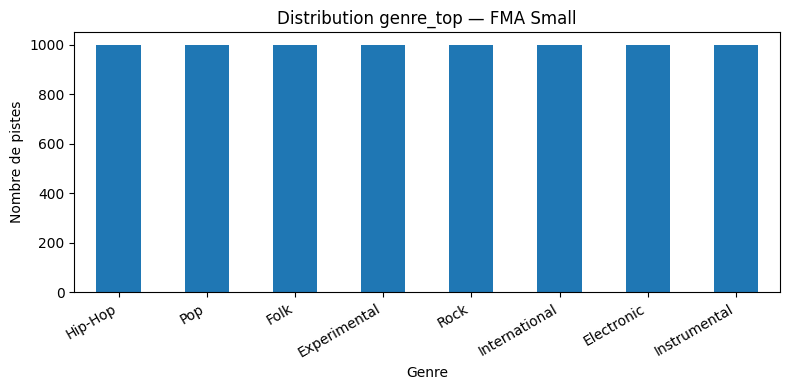

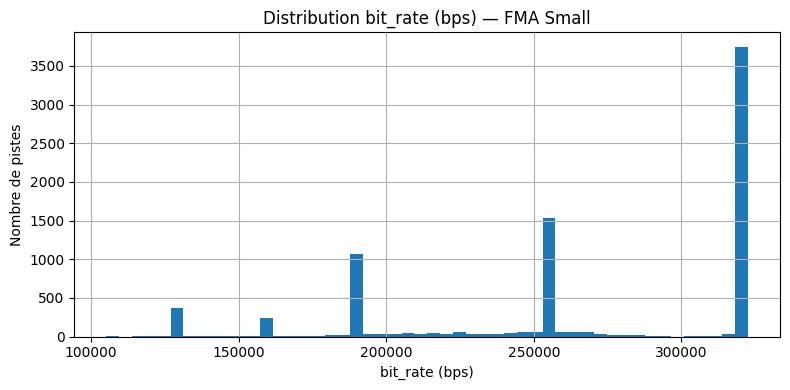

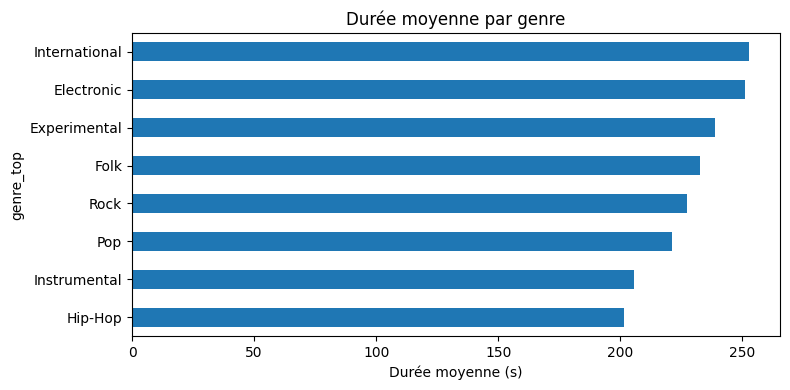

genre_top
Hip-Hop          201.6
Instrumental     205.5
Pop              221.2
Rock             227.2
Folk             232.5
Experimental     238.7
Electronic       251.3
International    252.8
Name: duration, dtype: float64


In [12]:
# C15
# 4.2. Sortie 2 - Distributions

# Distribution genre_top
genre_counts = small_tracks[("track", "genre_top")].value_counts()
print(genre_counts)

plt.figure(figsize=(8, 4))
genre_counts.plot(kind="bar")
plt.title("Distribution genre_top — FMA Small")
plt.xlabel("Genre")
plt.ylabel("Nombre de pistes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Distribution bit_rate
plt.figure(figsize=(8,4))
small_tracks[("track","bit_rate")].hist(bins=50)
plt.title("Distribution bit_rate (bps) — FMA Small")
plt.xlabel("bit_rate (bps)")
plt.ylabel("Nombre de pistes")
plt.tight_layout()
plt.show()

# Durée moyenne par genre (barh) + note “peu discriminant”
dur_mean = small_tracks["track"].groupby("genre_top")["duration"].mean().sort_values()
plt.figure(figsize=(8,4))
dur_mean.plot(kind="barh")
plt.title("Durée moyenne par genre")
plt.xlabel("Durée moyenne (s)")
plt.tight_layout()
plt.show()
print(dur_mean.round(1))

In [13]:
# C16
# 4.3. Sortie 3 - Sous-genres (préparation + top 20 + nb sous-genres)
genres_ref = pd.read_csv(GENRES_CSV, index_col=0)
id_to_title = genres_ref["title"].to_dict()

def decode_genres(x):
    try:
        ids = ast.literal_eval(str(x))
        return [id_to_title.get(i, str(i)) for i in ids]
    except Exception:
        return []

df = small_tracks.copy()
df["genre_top"] = df[("track", "genre_top")]
df["artist_name"] = df[("artist", "name")]
df["genres_decoded"] = df[("track", "genres")].apply(decode_genres)
df["n_subgenres"] = df["genres_decoded"].apply(len)

all_sub = [g for sub in df["genres_decoded"] for g in sub]
top20 = pd.Series(all_sub).value_counts().head(20)
print("Top 20 sous-genres:\n", top20)

print("\nDistribution nb sous-genres:\n", df["n_subgenres"].value_counts().sort_index())

Top 20 sous-genres:
 Hip-Hop              881
Folk                 772
Soundtrack           681
Instrumental         637
Experimental         585
Pop                  574
Electronic           529
Experimental Pop     403
Singer-Songwriter    373
Rock                 361
International        320
Ambient              249
Rap                  223
Indie-Rock           219
Avant-Garde          212
Reggae - Dub         206
Balkan               206
Dubstep              201
Noise                197
Synth Pop            176
Name: count, dtype: int64

Distribution nb sous-genres:
 n_subgenres
1    4256
2    2362
3    1304
4      41
5      32
6       5
Name: count, dtype: int64


Exemples retenus (genre -> track_id): {'Electronic': 1482, 'Experimental': 148, 'Folk': 140, 'Hip-Hop': 2, 'Instrumental': 10250, 'International': 666, 'Pop': 10, 'Rock': 182}


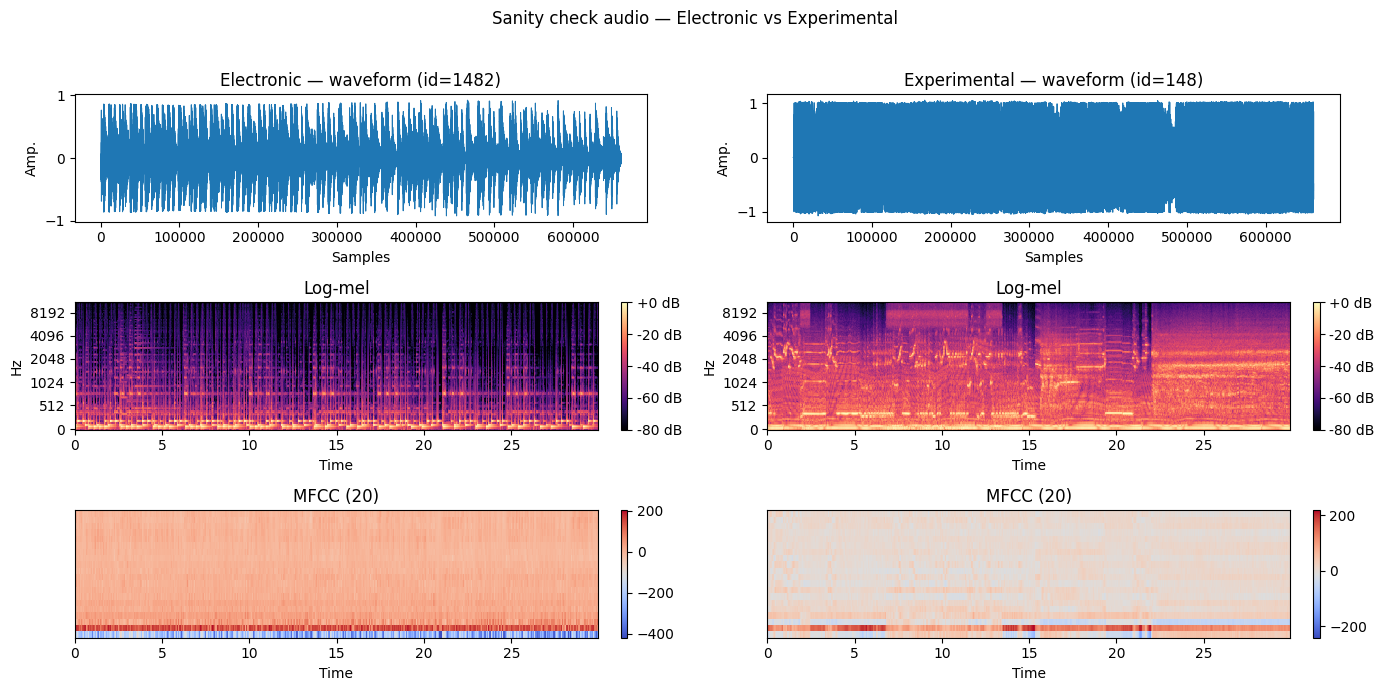

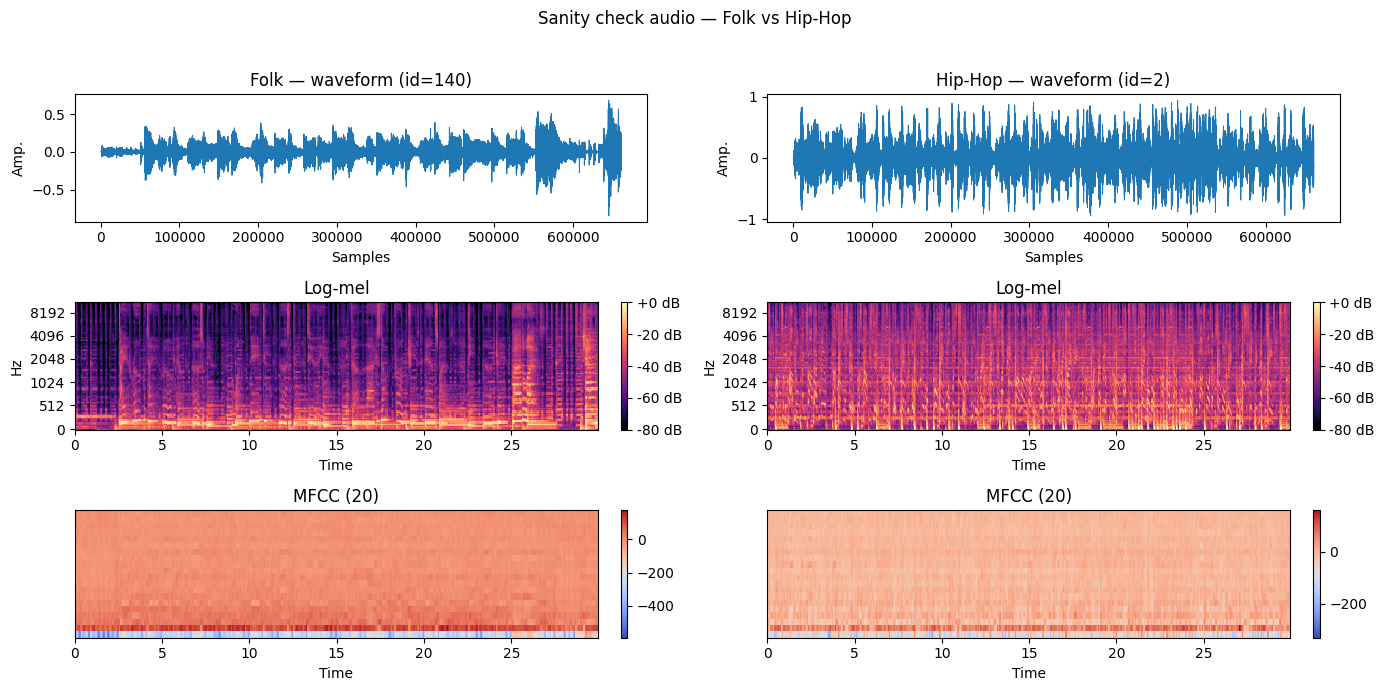

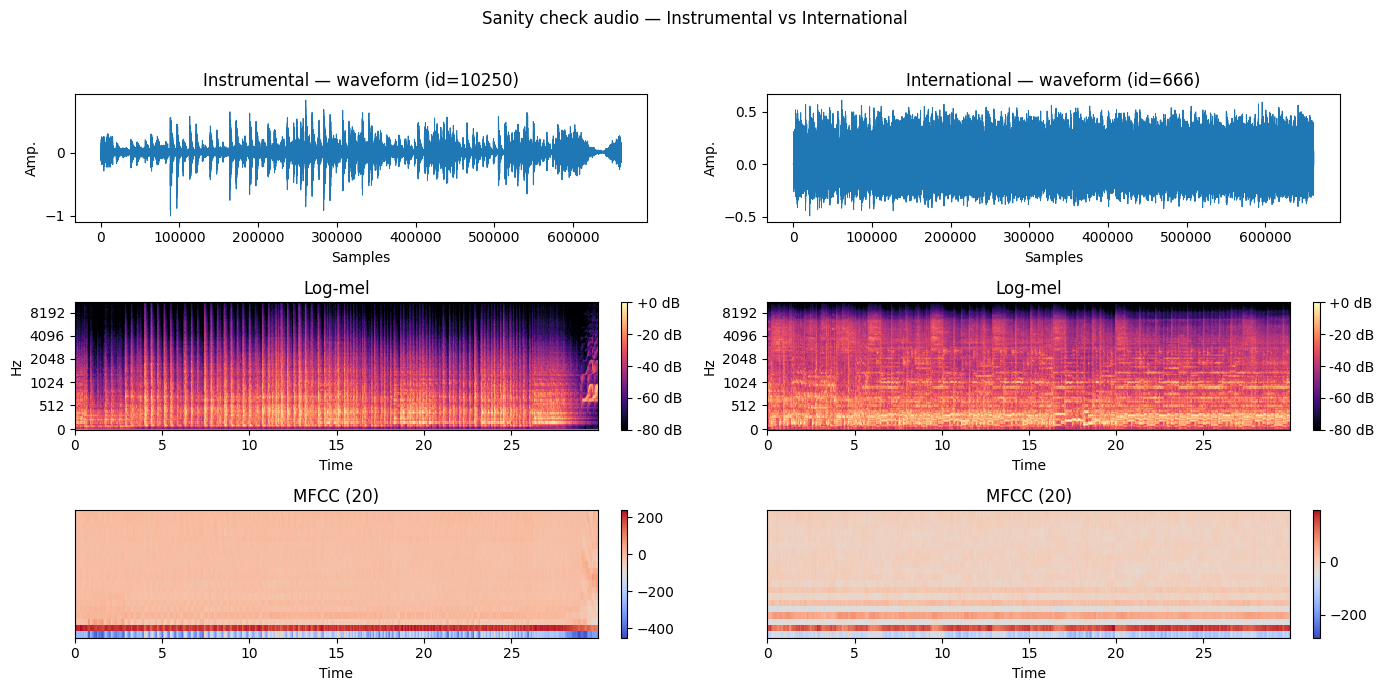

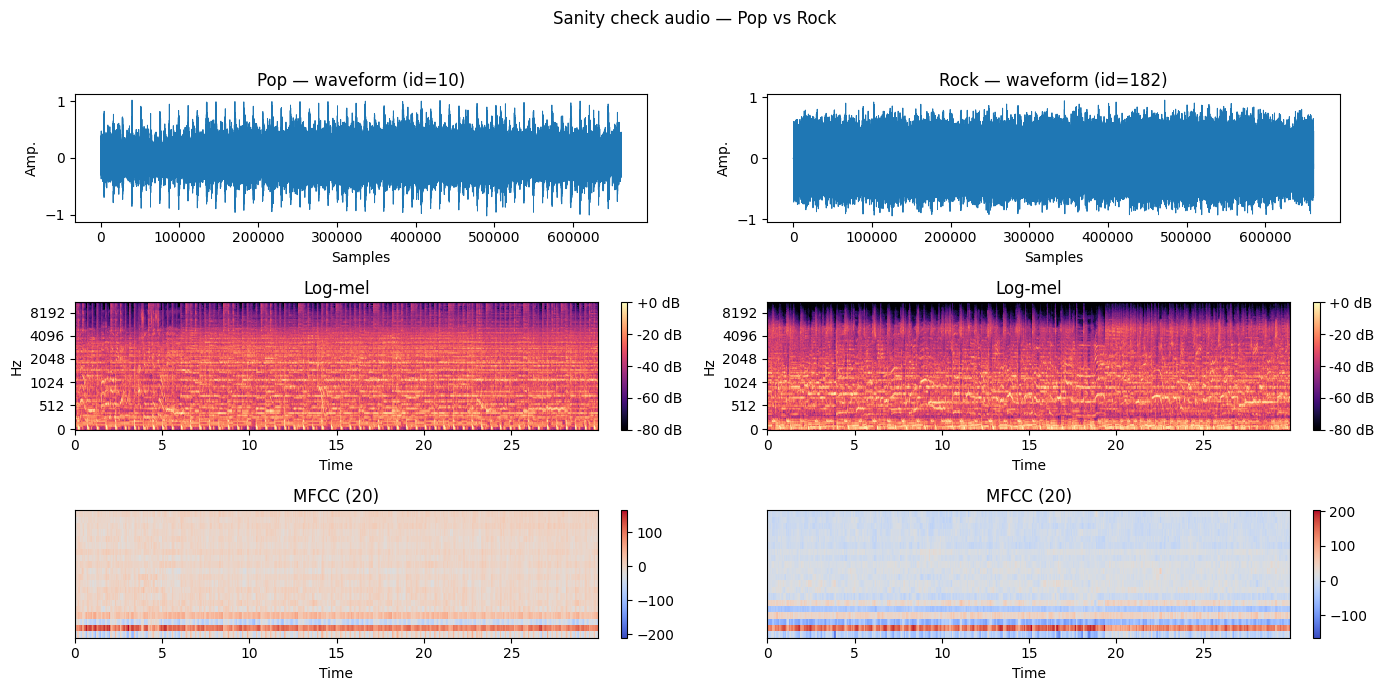

In [14]:
# C17
# 4.3.bis Visualisations Waveform + Spectrogram Log-mel + feature tabulaire MFCC sur les 8 classes
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert res["audio_decode_ok"], "Décodage audio KO : impossible de tracer waveform/spectrogram."

# track_id -> path mp3
mp3_map = {int(p.stem): str(p) for p in Path(AUDIO_DIR).rglob("*.mp3")}

# Liste des 8 classes (ordre stable)
genres = sorted(small_tracks[("track","genre_top")].astype(str).unique().tolist())

# 1 track_id par genre (premier ayant un mp3)
examples = {}
for g in genres:
    ids = small_tracks[small_tracks[("track","genre_top")].astype(str) == g].index.tolist()
    for tid in ids:
        tid = int(tid)
        if tid in mp3_map:
            examples[g] = tid
            break

print("Exemples retenus (genre -> track_id):", examples)

SR = 22050
DUR = 30.0

def compute_reprs(path):
    y, sr = librosa.load(path, mono=True, sr=SR, duration=DUR)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    logS = librosa.power_to_db(S, ref=np.max)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    return y, sr, logS, mfcc

# Grouper 2 genres par figure
genre_pairs = [(genres[i], genres[i+1]) for i in range(0, len(genres), 2)]

for g1, g2 in genre_pairs:
    tid1, tid2 = examples[g1], examples[g2]
    p1, p2 = mp3_map[tid1], mp3_map[tid2]

    y1, sr1, logS1, mfcc1 = compute_reprs(p1)
    y2, sr2, logS2, mfcc2 = compute_reprs(p2)

    fig, axes = plt.subplots(3, 2, figsize=(14, 7), gridspec_kw={"height_ratios":[1, 1, 1]})
    fig.suptitle(f"Sanity check audio — {g1} vs {g2}", fontsize=12)

    # Waveforms (ligne 1)
    axes[0,0].plot(y1, linewidth=0.7)
    axes[0,0].set_title(f"{g1} — waveform (id={tid1})")
    axes[0,0].set_xlabel("Samples")
    axes[0,0].set_ylabel("Amp.")

    axes[0,1].plot(y2, linewidth=0.7)
    axes[0,1].set_title(f"{g2} — waveform (id={tid2})")
    axes[0,1].set_xlabel("Samples")
    axes[0,1].set_ylabel("Amp.")

    # Log-mel (ligne 2)
    im10 = librosa.display.specshow(logS1, sr=sr1, x_axis="time", y_axis="mel", ax=axes[1,0])
    axes[1,0].set_title("Log-mel")
    plt.colorbar(im10, ax=axes[1,0], format="%+2.0f dB", fraction=0.046, pad=0.04)

    im11 = librosa.display.specshow(logS2, sr=sr2, x_axis="time", y_axis="mel", ax=axes[1,1])
    axes[1,1].set_title("Log-mel")
    plt.colorbar(im11, ax=axes[1,1], format="%+2.0f dB", fraction=0.046, pad=0.04)

    # MFCC (ligne 3)
    im20 = librosa.display.specshow(mfcc1, sr=sr1, x_axis="time", ax=axes[2,0])
    axes[2,0].set_title("MFCC (20)")
    plt.colorbar(im20, ax=axes[2,0], fraction=0.046, pad=0.04)

    im21 = librosa.display.specshow(mfcc2, sr=sr2, x_axis="time", ax=axes[2,1])
    axes[2,1].set_title("MFCC (20)")
    plt.colorbar(im21, ax=axes[2,1], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Mismatch global (%): 41.8

Mismatch % par genre:
 genre_top
Hip-Hop          12.4
Folk             22.8
Instrumental     36.3
Experimental     41.5
Pop              42.6
Electronic       47.1
Rock             63.9
International    68.0
Name: mismatch, dtype: float64


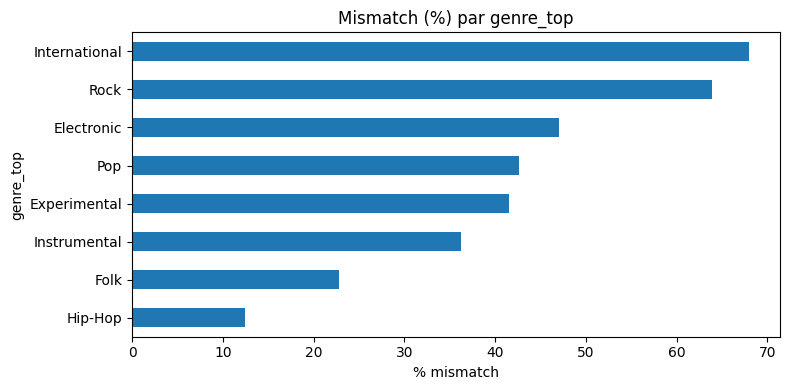

In [15]:
# C18
# 4.4. Sortie 4 - Mismatch (%) (robuste, sans apply ligne-à-ligne)

# Assurer des types simples
g = df["genre_top"].astype(str)

# genres_decoded doit être une vraie liste Python par ligne
# (si jamais certaines lignes sont NaN ou autre, on force en liste vide)
gd = df["genres_decoded"].apply(lambda x: x if isinstance(x, list) else [])

# mismatch = genre_top absent de la liste des sous-genres
df["mismatch"] = [gt not in lst for gt, lst in zip(g, gd)]

mismatch_global = df["mismatch"].mean() * 100
mismatch_by_genre = (df.groupby("genre_top")["mismatch"].mean() * 100).sort_values()

print("Mismatch global (%):", round(mismatch_global, 1))
print("\nMismatch % par genre:\n", mismatch_by_genre.round(1))

plt.figure(figsize=(8, 4))
mismatch_by_genre.plot(kind="barh")
plt.title("Mismatch (%) par genre_top")
plt.xlabel("% mismatch")
plt.tight_layout()
plt.show()

In [16]:
# C19
# 4.4.bis Analyse Mismatch

# Combos genre_top + sous-genres (Top 20)
df["genres_tuple"] = df["genres_decoded"].apply(lambda x: tuple(x) if isinstance(x, list) else tuple())
df["genre_combo"] = list(zip(df["genre_top"].astype(str), df["genres_tuple"]))

combo_counts = df["genre_combo"].value_counts().head(20)
print("Top 20 combos (genre_top, genres_decoded):\n", combo_counts)

# Mismatch par artiste (volume + % sur artistes >= 10 pistes)
mismatch_tracks = df[df["mismatch"] == True]

top_artists_mismatch = mismatch_tracks["artist_name"].value_counts().head(20)
print("\nTop 20 artistes (volume) avec mismatch:\n", top_artists_mismatch)

# % mismatch par artiste (min 10 pistes)
artist_counts = df["artist_name"].value_counts()
artists_10plus = artist_counts[artist_counts >= 10].index

mismatch_rate_artist = (
    df[df["artist_name"].isin(artists_10plus)]
    .groupby("artist_name")["mismatch"]
    .mean()
    .sort_values(ascending=False)
    .head(20) * 100
)

print("\nTop 20 artistes (% mismatch) — min 10 pistes:\n", mismatch_rate_artist.round(1))

# Profils de mismatch (erreur vs enrichissement) => analyse qualitative cadrée
# cas “mismatch géographique / macro-label” (International → Balkan/Reggae etc.) = ambiguïté structurelle
# cas “enrichissement stylistique” (Instrumental → Soundtrack/Ambient) = normal
# cas “suspicion erreur” (ex David Szesztay Instrumental mais sous-genres Folk) = candidat revue
def show_artist_profile(name):
    sub = df[df["artist_name"] == name]
    print(f"\n=== {name} ===")
    print("n_tracks:", len(sub))
    print("genre_top:", sub["genre_top"].value_counts().to_dict())
    all_g = [g for sublist in sub["genres_decoded"] if isinstance(sublist, list) for g in sublist]
    print("sous-genres:", pd.Series(all_g).value_counts().head(10).to_dict())

show_artist_profile("David Szesztay")      # profil suspect
show_artist_profile("Jelsonic")            # enrichissement (Soundtrack/Instrumental)
show_artist_profile("Black Sea Hotel")     # International -> Balkan (ambiguïté structurelle)

Top 20 combos (genre_top, genres_decoded):
 genre_combo
(Hip-Hop, (Hip-Hop,))                         598
(Folk, (Folk,))                               532
(Pop, (Pop,))                                 473
(Instrumental, (Soundtrack, Instrumental))    351
(Pop, (Experimental Pop,))                    307
(Folk, (Folk, Singer-Songwriter))             212
(Instrumental, (Soundtrack,))                 186
(International, (Reggae - Dub,))              176
(Hip-Hop, (Hip-Hop, Rap))                     152
(Instrumental, (Instrumental,))               150
(Experimental, (Experimental,))               119
(Rock, (Rock,))                               107
(Folk, (Singer-Songwriter,))                  107
(Instrumental, (Soundtrack, Ambient))          83
(International, (International,))              80
(Electronic, (Electronic,))                    78
(Pop, (Synth Pop,))                            76
(Instrumental, (Ambient,))                     73
(International, (Latin America,))           

Top sous-genres — Rock:
 Rock           361
Indie-Rock     219
Punk           167
Garage         151
Metal          102
Power-Pop       96
Post-Rock       94
Surf            93
Hardcore        90
Post-Punk       87
Psych-Rock      69
Progressive     65
Lo-Fi           50
New Wave        44
Noise-Rock      32
Name: count, dtype: int64

Top sous-genres — International:
 International         320
Reggae - Dub          206
Balkan                206
Europe                145
Latin America          99
Middle East            85
Romany (Gypsy)         58
African                45
Reggae - Dancehall     45
Turkish                45
Celtic                 40
Asia-Far East          37
Afrobeat               30
Latin                  29
Klezmer                29
Name: count, dtype: int64


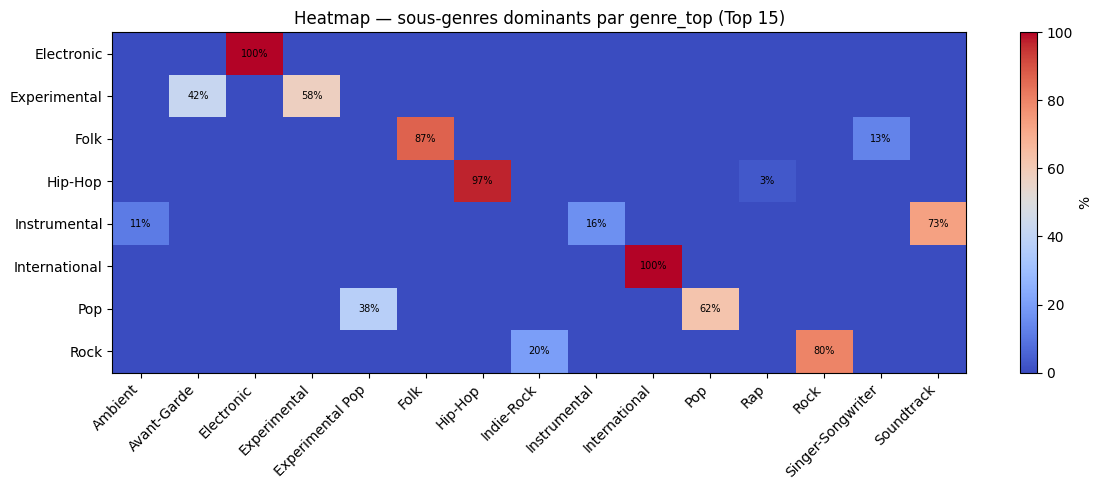

In [17]:
# C20
# 4.5. Sortie 5 - Focus Rock & International (robuste)

def top_subgenres_for(genre, n=15):
    subset = df[df["genre_top"].astype(str) == str(genre)]
    s = []
    for x in subset["genres_decoded"]:
        if isinstance(x, list):
            s.extend(x)
    return pd.Series(s).value_counts().head(n)

print("Top sous-genres — Rock:\n", top_subgenres_for("Rock", 15))
print("\nTop sous-genres — International:\n", top_subgenres_for("International", 15))

# Confusion genre_top vs sous-genres (Top 15 sous-genres globaux)
all_sub = [g for sublist in df["genres_decoded"] if isinstance(sublist, list) for g in sublist]
top_subgenres = pd.Series(all_sub).value_counts().head(15).index

conf = pd.crosstab(df["genre_top"], df["genres_decoded"].apply(lambda lst: lst[0] if isinstance(lst, list) and len(lst)>0 else "Unknown"))
conf_top = conf.loc[:, conf.columns.intersection(top_subgenres)]

# Normalisation par ligne (%) pour la heatmap
conf_pct = conf_top.div(conf_top.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
plt.imshow(conf_pct.values, aspect="auto", cmap="coolwarm", vmin=0, vmax=100)
plt.colorbar(label="%")

plt.yticks(range(conf_pct.shape[0]), conf_pct.index)
plt.xticks(range(conf_pct.shape[1]), conf_pct.columns, rotation=45, ha="right")

# Annotations: afficher le % dans chaque case (on évite de surcharger avec des zéros)
for i in range(conf_top.shape[0]):
    for j in range(conf_top.shape[1]):
        n = int(conf_top.iloc[i, j])
        if n > 0:
            p = float(conf_pct.iloc[i, j])
            plt.text(j, i, f"{p:.0f}%", ha="center", va="center", fontsize=7, color="black")

plt.title("Heatmap — sous-genres dominants par genre_top (Top 15)")
plt.tight_layout()
plt.show()

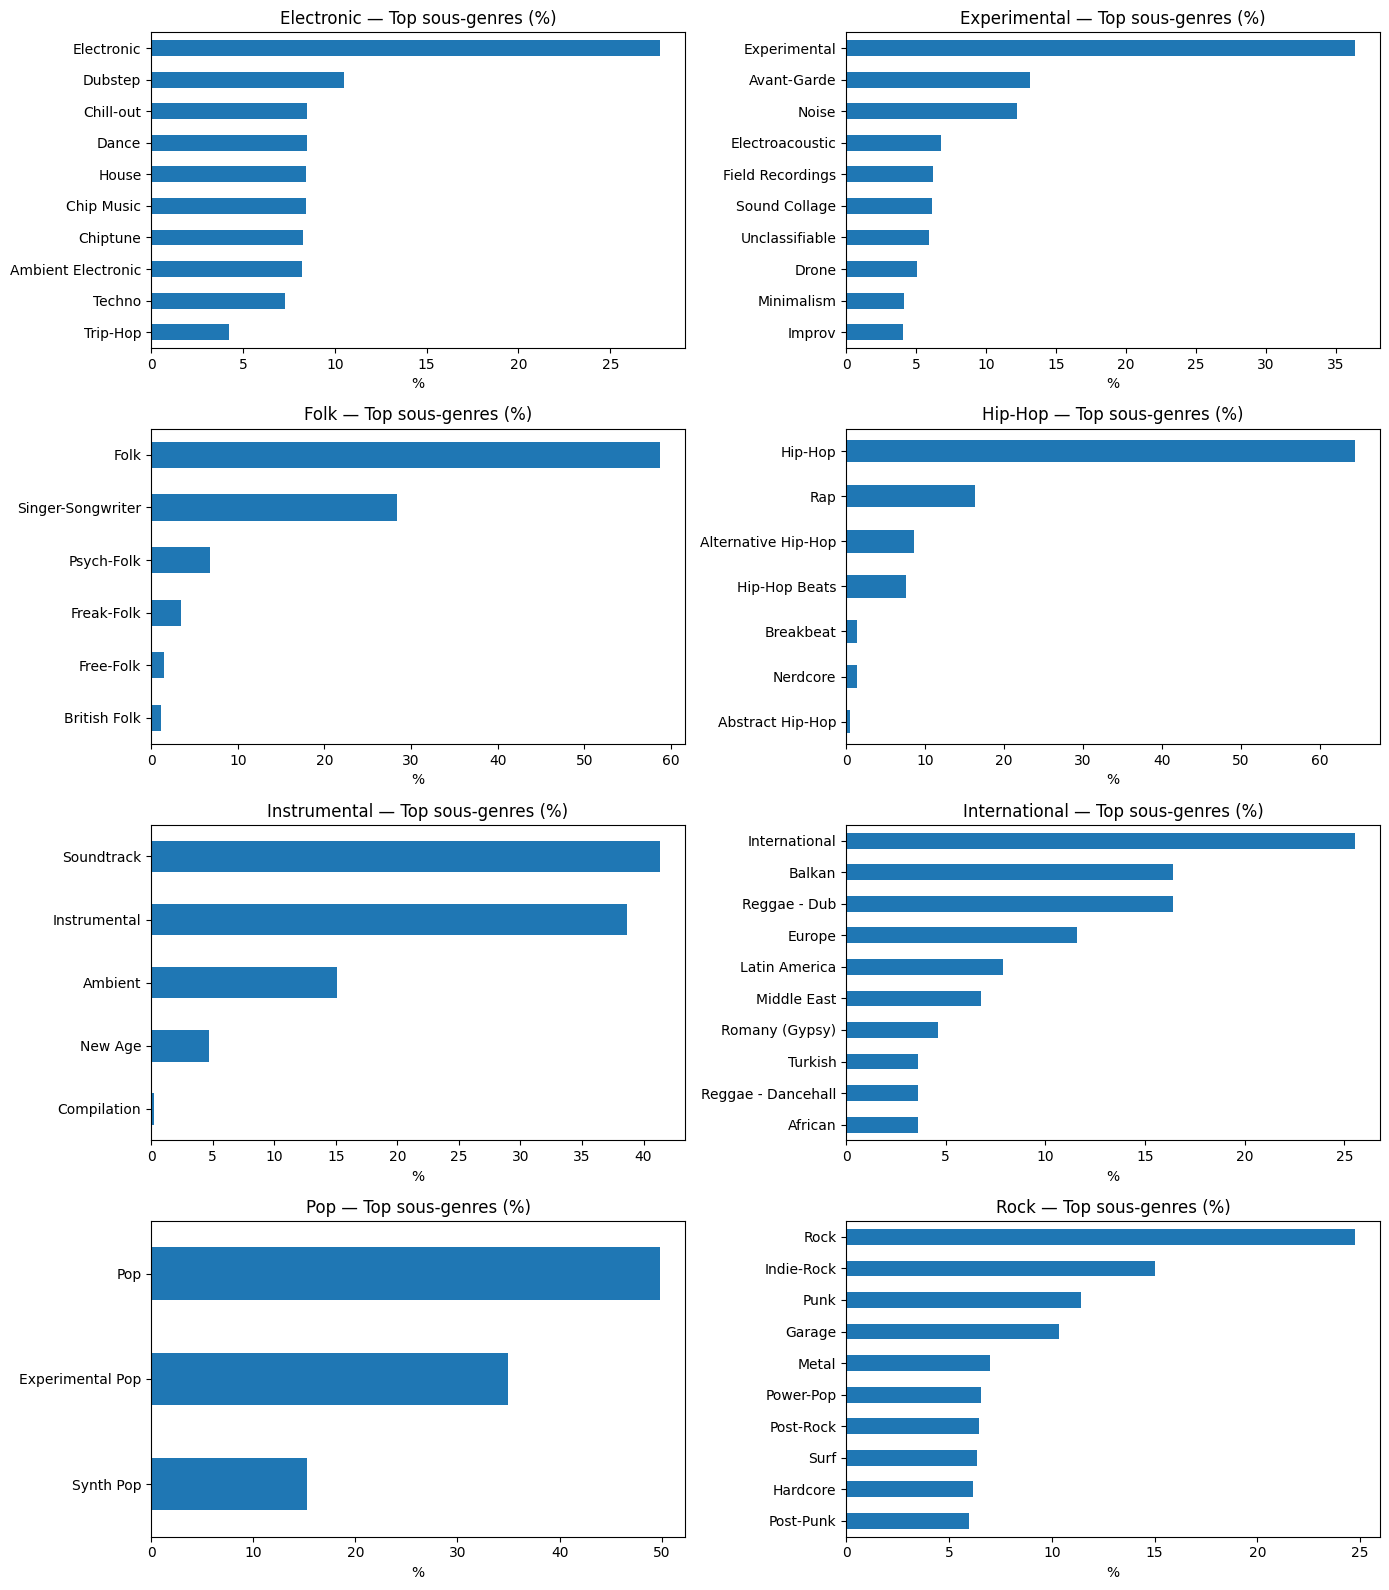

In [18]:
# C21
# 4.5.bis Histogrammes “sous-genres par genre”

# Top 10 par genre, en %
genres = df["genre_top"].unique().tolist()
genres = sorted(genres)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, gtop in enumerate(genres):
    subset = df[df["genre_top"] == gtop]
    s = [g for sublist in subset["genres_decoded"] if isinstance(sublist, list) for g in sublist]
    vc = pd.Series(s).value_counts().head(10)
    vc_pct = (vc / vc.sum() * 100).sort_values(ascending=True)

    vc_pct.plot(kind="barh", ax=axes[i])
    axes[i].set_title(f"{gtop} — Top sous-genres (%)")
    axes[i].set_xlabel("%")

plt.tight_layout()
plt.show()

In [19]:
# C22
# 4.6. Sortie 6 - Biais artiste + tableau “difficulté attendue”

# Sécuriser artist_name (au cas où)
df["artist_name"] = df["artist_name"].fillna("Unknown")

def artist_concentration(g):
    vc = g["artist_name"].value_counts()
    top1_share = vc.iloc[0] / len(g)
    top5_share = vc.iloc[:5].sum() / len(g)
    return pd.Series({
        "n_tracks": len(g),
        "n_artists": g["artist_name"].nunique(),
        "top1_artist": vc.index[0],
        "top1_share_%": round(top1_share * 100, 1),
        "top5_share_%": round(top5_share * 100, 1),
    })

bias_table = df.groupby("genre_top").apply(artist_concentration).sort_values("top1_share_%", ascending=False)
print("Biais artistes (par genre):\n", bias_table)

# Recalcul mismatch_by_genre (source of truth = df)
mismatch_by_genre = (df.groupby("genre_top")["mismatch"].mean() * 100)

# Aligner les index (sécurité)
mismatch_by_genre = mismatch_by_genre.reindex(bias_table.index)

difficulty = pd.DataFrame({
    "mismatch_%": mismatch_by_genre.round(1),
    "top1_artist_%": bias_table["top1_share_%"],
}).sort_values(["mismatch_%", "top1_artist_%"], ascending=False)

print("\nTableau difficulté attendue:\n", difficulty)
print("\nHypothèse: mismatch élevé et/ou top1_artist_% élevé -> plus de confusions en confusion matrix.")

Biais artistes (par genre):
                n_tracks  n_artists                     top1_artist  \
genre_top                                                            
Instrumental       1000        120               Blue Dot Sessions   
Folk               1000        249                       Big Blood   
Hip-Hop            1000        194                The Impossebulls   
Pop                1000        297                         Phemale   
Electronic         1000        360                            SPCZ   
Experimental       1000        482                File Under Toner   
International      1000        255  Turku, Nomads of the Silk Road   
Rock               1000        448                 The Vivisectors   

               top1_share_%  top5_share_%  
genre_top                                  
Instrumental           20.8          37.3  
Folk                    9.1          19.8  
Hip-Hop                 6.8          23.1  
Pop                     4.1          13.9  
Electr

C:\Users\maison\AppData\Local\Temp\ipykernel_12240\975013518.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bias_table = df.groupby("genre_top").apply(artist_concentration).sort_values("top1_share_%", ascending=False)


Top 5 artistes Instrumental:
 artist_name
Blue Dot Sessions    208
Squire Tuck           50
TRG Banks             47
Cory Gray             36
David Szesztay        32
Name: count, dtype: int64

Blue Dot Sessions — nb pistes: 208 — années: {2015: 186, 2016: 17, 2017: 5}

Squire Tuck — nb pistes: 50 — années: {2015: 37, 2016: 13}

TRG Banks — nb pistes: 47 — années: {2016: 47}

Cory Gray — nb pistes: 36 — années: {2015: 36}

David Szesztay — nb pistes: 32 — années: {2016: 32}


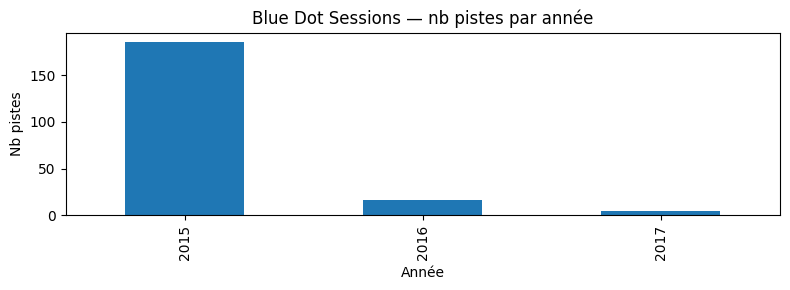

Sous-genres Blue Dot Sessions:
 Instrumental    208
Soundtrack      201
Name: count, dtype: int64


In [20]:
# C23
# 4.6.bis Analyse Blue Dot Sessions + top 5 Instrumental + années

# Top artistes dans Instrumental + concentration temporelle
inst = df[df["genre_top"] == "Instrumental"].copy()
top_art = inst["artist_name"].value_counts().head(5)
print("Top 5 artistes Instrumental:\n", top_art)

# Parse année
years = pd.to_datetime(df[("track","date_created")], errors="coerce").dt.year
df_year = df.copy()
df_year["year"] = years

top5_names = top_art.index.tolist()
for a in top5_names:
    sub = df_year[(df_year["genre_top"] == "Instrumental") & (df_year["artist_name"] == a)]
    print(f"\n{a} — nb pistes: {len(sub)} — années:", sub["year"].value_counts().sort_index().to_dict())

# Blue Dot par année
bd = df_year[df_year["artist_name"] == "Blue Dot Sessions"]
bd_counts = bd["year"].value_counts().sort_index()
bd_counts.plot(kind="bar", figsize=(8,3))
plt.title("Blue Dot Sessions — nb pistes par année")
plt.xlabel("Année")
plt.ylabel("Nb pistes")
plt.tight_layout()
plt.show()

# Sous-genres Blue Dot Sessions
bd_subgenres = [g for sublist in df[df["artist_name"] == "Blue Dot Sessions"]["genres_decoded"] 
                if isinstance(sublist, list) for g in sublist]
print("Sous-genres Blue Dot Sessions:\n", pd.Series(bd_subgenres).value_counts())

Volumes par année (toutes classes):
year
2008     248
2009     692
2010     686
2011     887
2012     884
2013     930
2014     877
2015    1507
2016    1196
2017      93
Name: count, dtype: int64


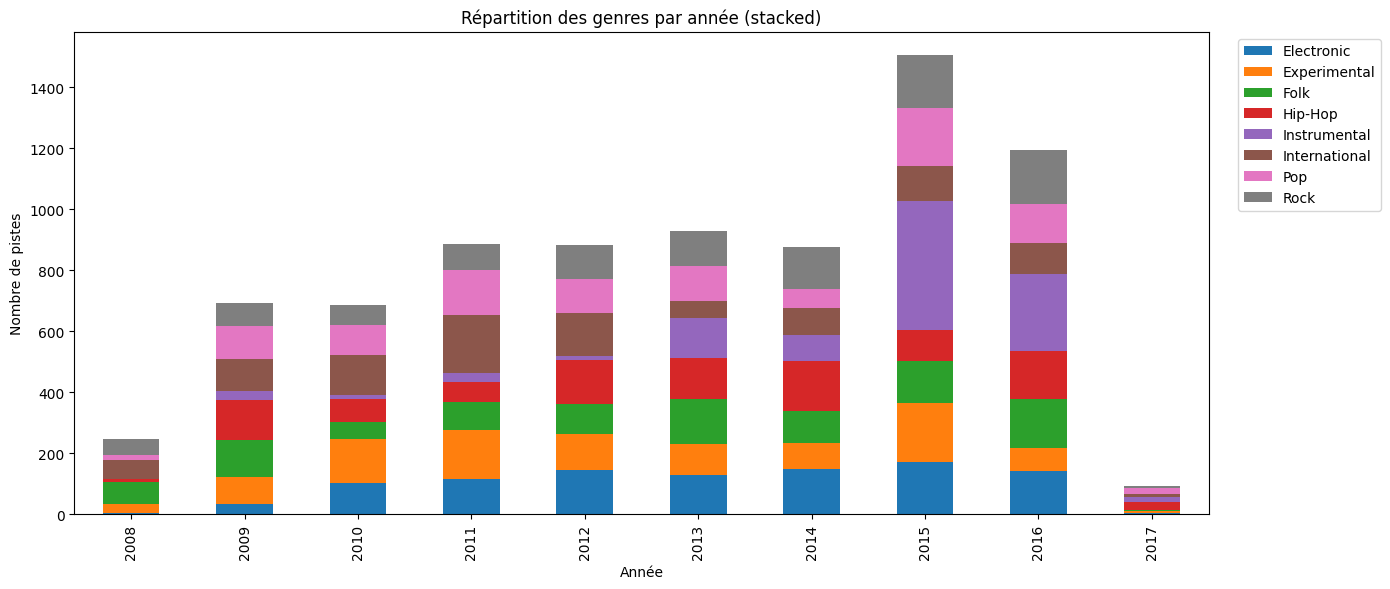

In [21]:
# C24
# 4.7. Sortie 7 (optionnelle) — Biais temporel (diagnostic)
# Stacked bar : répartition des genres par année

years = pd.to_datetime(small_tracks[("track","date_created")], errors="coerce").dt.year
tmp = pd.DataFrame({
    "year": years,
    "genre_top": small_tracks[("track","genre_top")].astype(str)
}).dropna()

# Option: exclure 2017 si volume trop faible
# tmp = tmp[tmp["year"] <= 2016]

print("Volumes par année (toutes classes):")
print(tmp["year"].value_counts().sort_index())

pivot = tmp.pivot_table(index="year", columns="genre_top", aggfunc="size", fill_value=0).sort_index()

pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.title("Répartition des genres par année (stacked)")
plt.xlabel("Année")
plt.ylabel("Nombre de pistes")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
# C25
# 4.7.bis Durée : mismatch vs non-mismatch (diagnostic)
df_analysis = pd.DataFrame({
    "genre_top": df["genre_top"].astype(str),
    "mismatch": df["mismatch"].astype(bool),
}, index=df.index)

df_analysis["duration"] = pd.to_numeric(
    small_tracks.loc[df_analysis.index, ("track","duration")],
    errors="coerce"
)

summary = df_analysis.groupby("mismatch")["duration"].describe()
print(summary)

mean_diff = summary.loc[True, "mean"] - summary.loc[False, "mean"]
print("\nDifférence moyenne (mismatch - non-mismatch) en secondes:", round(mean_diff, 2))

# Conclusion rapport-ready (à garder en markdown)
print("\nConclusion: la durée n'est pas discriminante (écarts faibles vs variance intra-genre).")

           count        mean         std   min    25%    50%     75%    max
mismatch                                                                   
False     4654.0  225.669102   94.471844  60.0  163.0  213.0  272.00  600.0
True      3346.0  233.254035  103.457441  60.0  159.0  219.0  288.75  600.0

Différence moyenne (mismatch - non-mismatch) en secondes: 7.58

Conclusion: la durée n'est pas discriminante (écarts faibles vs variance intra-genre).


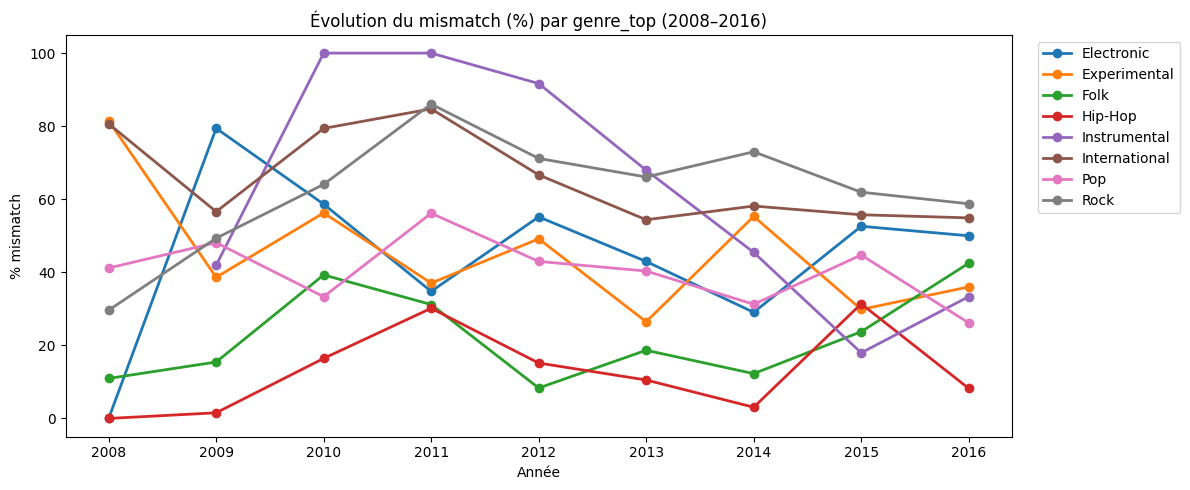

In [23]:
# C26
# 4.7.ter Évolution temporelle des mismatches (on exclut 2017 car incomplet)
df_year = df.copy() # recréé ici pour permettre l'exécution indépendante de C23
df_year["year"] = pd.to_datetime(df[("track","date_created")], errors="coerce").dt.year

mismatch_by_year_genre = (df_year.groupby(["year","genre_top"])["mismatch"].mean()*100).unstack()

# garder 2008-2016 si 2017 est trop faible
mismatch_by_year_genre = mismatch_by_year_genre.loc[2008:2016]

mismatch_by_year_genre.plot(figsize=(12,5), marker="o", linewidth=2)
plt.title("Évolution du mismatch (%) par genre_top (2008–2016)")
plt.xlabel("Année")
plt.ylabel("% mismatch")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [24]:
# C27
# 5. Décisions figées (après EDA)
# Ces paramètres sont gelés et doivent être identiques pour tous les notebooks de modélisation

STANDARD = {"mono": True, "sr": 22050, "window_s": 30}

SUBGENRES_STRATEGY = {"default": "top-k", "k": 3, "multi_label_if_time": True, "freq_threshold": 50}

SPLIT_STRATEGY = {
    "preferred": "group_split_by_artist",
    "test_size": 0.2,
    "random_state": 42,
    "fallback": "stratified_split_genre_top_and_document_bias"
}

EVAL_STRATEGY = {
    "primary_metric": "macro_f1",  # classes équilibrées mais hétérogènes → F1 macro plus informatif qu'accuracy
    "secondary_metric": "accuracy",
    "confusion_matrix": True       # obligatoire pour valider l'hypothèse mismatch → erreurs
}

# Vérification faisabilité group split
print("=== Faisabilité group split par artiste ===")
artist_counts = df["artist_name"].value_counts()
print(f"Artistes uniques : {len(artist_counts)}")
print(f"Artistes avec > 1 piste : {(artist_counts > 1).sum()}")
print(f"Artistes avec > 10 pistes : {(artist_counts > 10).sum()}")
print(f"\nTop 5 artistes (concentration) :")
print(artist_counts.head(5))
print(f"\nBlue Dot Sessions : {artist_counts.get('Blue Dot Sessions', 0)} pistes "
      f"({artist_counts.get('Blue Dot Sessions', 0)/len(df)*100:.1f}% du dataset)")

# Vérification seuil freq_threshold sous-genres
print("\n=== Sous-genres atteignant le seuil freq_threshold=50 ===")
all_sub = [g for sublist in df["genres_decoded"] if isinstance(sublist, list) for g in sublist]
sub_counts = pd.Series(all_sub).value_counts()
eligible = sub_counts[sub_counts >= 50]
print(f"Sous-genres >= 50 occurrences : {len(eligible)}")
print(eligible)

STANDARD, SUBGENRES_STRATEGY, SPLIT_STRATEGY, EVAL_STRATEGY

=== Faisabilité group split par artiste ===
Artistes uniques : 2306
Artistes avec > 1 piste : 1111
Artistes avec > 10 pistes : 126

Top 5 artistes (concentration) :
artist_name
Blue Dot Sessions    208
Big Blood             91
The Impossebulls      68
Squire Tuck           56
Kellee Maize          55
Name: count, dtype: int64

Blue Dot Sessions : 208 pistes (2.6% du dataset)

=== Sous-genres atteignant le seuil freq_threshold=50 ===
Sous-genres >= 50 occurrences : 61
Hip-Hop               881
Folk                  772
Soundtrack            681
Instrumental          637
Experimental          585
                     ... 
Audio Collage          60
Romany (Gypsy)         58
Minimal Electronic     52
Holiday                51
Lo-Fi                  50
Name: count, Length: 61, dtype: int64


({'mono': True, 'sr': 22050, 'window_s': 30},
 {'default': 'top-k',
  'k': 3,
  'multi_label_if_time': True,
  'freq_threshold': 50},
 {'preferred': 'group_split_by_artist',
  'test_size': 0.2,
  'random_state': 42,
  'fallback': 'stratified_split_genre_top_and_document_bias'},
 {'primary_metric': 'macro_f1',
  'secondary_metric': 'accuracy',
  'confusion_matrix': True})

---
## Conclusion EDA & transition vers l'extraction features V2
---

### Ce que l'EDA a établi
- Dataset techniquement propre, pipeline audio validé → extraction V2 peut démarrer
- 8 classes équilibrées, mismatch documenté par genre → hypothèse testable en Phase 3
- Biais artiste identifié (Blue Dot Sessions) → group split par artiste obligatoire
- Métrique cible figée : **macro F1** + matrice de confusion

### Préparation DL (sans exécution dans ce notebook)
- Représentation : log-mel spectrogram (déjà visualisé en C17)
- Split : identique au ML tabulaire (group split artiste)
- Standardisation : identique (`mono`, `sr=22050`, `30s`)

### Préparation clustering (piste future)
- Clustering possible sur features V2 ou embeddings DL
- Usage potentiel : navigation catalogue, regroupements mood

### Next step — extraction V2
Lancer `NOTEBOOK2_FEATURES.ipynb` :
- 351 features par piste (10 familles × 7 stats + tempo scalaire) — détail dans `NOTEBOOK2_FEATURES.ipynb`
- Logs + checkpoints toutes les 200 pistes
- Sauvegarder `features_V2.csv` — **ne jamais réextraire**
- Comparer avec `features.csv` FMA sur les features communes (validation pipeline)

---